<a href="https://colab.research.google.com/github/gtabot/pix2pix-test/blob/main/Copy_of_Pix2Pix_tf_training_Jul_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Train a pix2pix model with Tensorflow



This code will allow you to train a pix2pix model on two folders of corresponding A & B images. Make sure you are connected to a T4 runtime before running the code.

## Install necessary packages and connect to google drive:

In [ ]:
# Clone the repository
!git clone https://github.com/affinelayer/pix2pix-tensorflow.git
%cd pix2pix-tensorflow

# Patch the old TF1 code to work with modern Colab's TF2 environment
!sed -i 's/import tensorflow as tf/import tensorflow.compat.v1 as tf\ntf.disable_v2_behavior()/g' pix2pix.py
!sed -i 's/import tensorflow as tf/import tensorflow.compat.v1 as tf\ntf.disable_v2_behavior()/g' server/tools/export-checkpoint.py

print("Repo cloned and patched successfully!")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Cloning into 'pix2pix-tensorflow'...
remote: Enumerating objects: 261, done.
remote: Total 261 (delta 0), reused 0 (delta 0), pack-reused 261 (from 1)
Receiving objects: 100% (261/261), 13.33 MiB | 17.21 MiB/s, done.
Resolving deltas: 100% (103/103), done.
/content/pix2pix-tensorflow
Repo cloned and patched successfully!


ValueError: Mountpoint must not already contain files

## Replace these folder paths with the path to your image folder and the path to where you want to save the converted images:


- `A_DIR` — your folder of input/source images
- `B_DIR` — your folder of target/output images
- `OUTPUT_DIR` — where the finished side-by-side training images will be saved
- `CKPT_DIR` - where to save your model checkpoints
- `FINAL_MODEL` - where to save your final model file eventually

The A and B folders should contain images with **matching filenames** — the script pairs them by name.

In [ ]:
# ── EDIT THESE FIVE PATHS ──────────────────────────────────────────────────
A_DIR = "/content/drive/MyDrive/Colab Notebooks/pix2pix/A"
B_DIR = "/content/drive/MyDrive/Colab Notebooks/pix2pix/B"
OUTPUT_DIR = "/content/drive/MyDrive/Colab Notebooks/pix2pix/output"
CKPT_DIR = "/content/drive/MyDrive/Colab Notebooks/pix2pix/ckpt"
FINAL_MODEL = "/content/drive/MyDrive/Colab Notebooks/pix2pix/shoes.pict"
# ────────────────────────────────────────────────────────────────────────────

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"A images   : {A_DIR}")
print(f"B images   : {B_DIR}")
print(f"Output dir : {OUTPUT_DIR}")

A images   : /content/drive/MyDrive/Colab Notebooks/pix2pix/A
B images   : /content/drive/MyDrive/Colab Notebooks/pix2pix/B
Output dir : /content/drive/MyDrive/Colab Notebooks/pix2pix/output


## Make sure all images are indeed 256 x 256px and save to a temp folder for compositing in next step



In [ ]:
from PIL import Image
import os

TARGET_SIZE = (256, 256)
VALID_EXTS  = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

def resize_folder(src_dir, dst_dir, label):
    """Resize every image in src_dir to 256x256 and save to dst_dir."""
    os.makedirs(dst_dir, exist_ok=True)
    files = [f for f in sorted(os.listdir(src_dir))
             if os.path.splitext(f)[1].lower() in VALID_EXTS]
    print(f"Resizing {len(files)} {label} images...")
    for fname in files:
        src_path = os.path.join(src_dir, fname)
        dst_name = os.path.splitext(fname)[0] + ".png"  # save as PNG
        dst_path = os.path.join(dst_dir, dst_name)

        img = Image.open(src_path).convert("RGB")


        img = img.resize(TARGET_SIZE, Image.LANCZOS)



        img.save(dst_path)
    print(f"  Done — saved to {dst_dir}")
    return files  # return list so we can check counts match

a_files = resize_folder(A_DIR, "/content/A_resized", "A")
b_files = resize_folder(B_DIR, "/content/B_resized", "B")

# Sanity check: A and B should have the same number of images
a_stems = {os.path.splitext(f)[0] for f in a_files}
b_stems = {os.path.splitext(f)[0] for f in b_files}
missing = a_stems.symmetric_difference(b_stems)
if missing:
    print(f"WARNING: {len(missing)} filenames appear in only one folder: {sorted(missing)[:10]}")
else:
    print(f"All {len(a_stems)} filenames match between A and B. Ready to combine.")

Resizing 300 A images...
  Done — saved to /content/A_resized
Resizing 300 B images...
  Done — saved to /content/B_resized
All 300 filenames match between A and B. Ready to combine.


## Combine A and B images into side-by-side pairs

pix2pix doesn't take A and B as separate files. It expects a single image that is **512 × 256 pixels wide**, with the A image on the left half and the B image on the right half (or vice versa, depending on training direction).

This cell pairs each resized A image with its matching B image by filename, stitches them together horizontally, and saves the result to your output folder.

Combined 300 image pairs → /content/drive/MyDrive/Colab Notebooks/pix2pix/shoes.pict


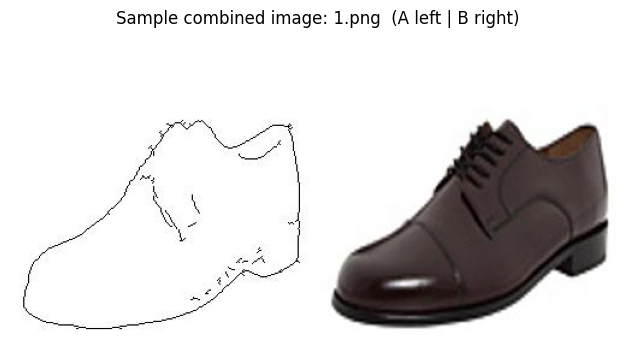

In [ ]:
from PIL import Image
import os

# Ensure the output directory exists before saving files
os.makedirs(OUTPUT_DIR, exist_ok=True)

A_RESIZED = "/content/A_resized" # Corrected: A images are in /content/A_resized
B_RESIZED = "/content/B_resized" # Corrected: B images are in /content/B_resized

a_files = sorted([
    f for f in os.listdir(A_RESIZED)
    if f.lower().endswith(".png")
])

combined_count = 0
skipped = []

for fname in a_files:
    a_path = os.path.join(A_RESIZED, fname)
    b_path = os.path.join(B_RESIZED, fname)  # same filename in B folder

    if not os.path.exists(b_path):
        skipped.append(fname)
        continue

    img_a = Image.open(a_path).convert("RGB")
    img_b = Image.open(b_path).convert("RGB")

    # Create a 512x256 canvas and paste A on left, B on right
    combined = Image.new("RGB", (512, 256))
    combined.paste(img_a, (0, 0))    # A goes on the LEFT  (input)
    combined.paste(img_b, (256, 0))  # B goes on the RIGHT (target)

    out_path = os.path.join(OUTPUT_DIR, fname)
    combined.save(out_path)
    combined_count += 1

print(f"Combined {combined_count} image pairs → {OUTPUT_DIR}")
if skipped:
    print(f"Skipped {len(skipped)} A images with no matching B file: {skipped[:5]}")

# Quick preview of the first combined image
import matplotlib.pyplot as plt
if combined_count > 0:
    sample = Image.open(os.path.join(OUTPUT_DIR, a_files[0]))
    plt.figure(figsize=(10, 4))
    plt.imshow(sample)
    plt.axis("off")
    plt.title(f"Sample combined image: {a_files[0]}  (A left | B right)")
    plt.show()

## Train the model

This is the main training code block. It reads all the combined images from your `combined/train` folder and trains the pix2pix network for 200 epochs, learning to translate images from the A side to the B side (`--which_direction AtoB`).

- `--lr` the learning rate sets how big of a correction the model makes each time it learns from a mistake. It's like adjusting a shower knob: big steps get you close to the right temperature fast but risk overshooting into scalding or freezing, while tiny steps take longer but let you settle in precisely without swinging past the target, which is why a lower learning rate trades speed for more stable, reliable training. You can reduce the lr to 0.0001 if you want but it will take longer to train.
- `--save_freq` This specifies how often (in training steps) the model should save a checkpoint to the `output_dir` (which is `CKPT_DIR`). Saving frequently helps you recover progress if training is interrupted.
*   `--display_freq 500`: This flag determines how often (in training steps) the script generates and saves example output images. These are helpful for visually monitoring the progress of the image translation during training.
- The checkpoint is saved to `ckpt_atob/`. The old folder is deleted first to avoid loading a corrupted previous run.



### How to Resume Training

Run the code block after the next one...

In [ ]:
!rm -rf "{CKPT_DIR}" #VERY IMPORTANT: COMMENT THIS LINE OUT IF YOU ARE RESUMING TRAINING ***

# 2. Recreate the folder
!mkdir -p "{CKPT_DIR}"

# 3. Train in the correct direction WITH the lower learning rate
!TF_USE_LEGACY_KERAS=1 python pix2pix.py \
  --mode train \
  --input_dir "{OUTPUT_DIR}" \
  --output_dir "{CKPT_DIR}" \
  --which_direction AtoB \
  --max_epochs 200 \
  --lr 0.0001 \
  --save_freq 100 \
  --display_freq 500 #\
  #--checkpoint "{CKPT_DIR}"

python3: can't open file '/content/pix2pix.py': [Errno 2] No such file or directory


## RESUME TRAINING

run the next code block to resume training instead of starting over.

In [ ]:


# 3. Train in the correct direction WITH the lower learning rate
!TF_USE_LEGACY_KERAS=1 python pix2pix.py \
  --mode train \
  --input_dir "{OUTPUT_DIR}" \
  --output_dir "{CKPT_DIR}" \
  --which_direction AtoB \
  --max_epochs 200 \
  --lr 0.0001 \
  --save_freq 100 \
  --display_freq 500 \
  --checkpoint "{CKPT_DIR}"

python3: can't open file '/content/pix2pix.py': [Errno 2] No such file or directory


## Export the trained model

Once training finishes, this cell freezes the saved checkpoint into a portable `export/` folder and then converts it into a `.pict` file. The `.pict` format is what the pix2pix interactive demo expects. The finished file is also copied back to your Google Drive so it's safe even after the Colab session ends.

In [ ]:
!mkdir -p export
!mkdir -p static/models
!pip install tensorflow==1.15
print("Freezing Epoch 40 model...")
!TF_USE_LEGACY_KERAS=1 python pix2pix.py \
  --mode export \
  --output_dir export/ \
  --checkpoint "{CKPT_DIR}" \
  --which_direction AtoB

print("Converting to .pict...")
!TF_USE_LEGACY_KERAS=1 python server/tools/export-checkpoint.py \
  --checkpoint export/ \
  --output_file static/models/my_custom_model.pict

!cp static/models/my_custom_model.pict "{FINAL_MODEL}" #SAVE FINAL MODEL
print("Done! Your Epoch 40 .pict file is ready.")

## Fix TF1 compatibility and re-export (run only if Step 7 failed)

If the previous step threw an `AttributeError` about `NewCheckpointReader`, it means a sub-script inside the repo also needs to be patched for TF2. This cell applies that patch and then re-runs the `.pict` conversion. You only need to run this if the previous cell errored.

In [ ]:
# 1. Patch the hidden sub-script for TensorFlow 1.x compatibility
!sed -i 's/import tensorflow as tf/import tensorflow.compat.v1 as tf\ntf.disable_v2_behavior()/g' server/tools/dump_checkpoints/tensorflow_checkpoint_dumper.py

# 2. Re-run the .pict conversion
print("Converting to .pict...")
!TF_USE_LEGACY_KERAS=1 python server/tools/export-checkpoint.py \
  --checkpoint export/ \
  --output_file static/models/my_custom_model.pict

# 3. Save it to your Drive
!cp static/models/my_custom_model.pict "{FINAL_MODEL}" #
print("Done! Your .pict file should now be in your folder.")